# 10장 실습 — 갭 측정과 MMRV

3부가 정책 셋을 넘겼다. 4부는 그 정책들이 **시뮬레이터에서 현장으로 옮겨질 때** 무슨 일이 생기는지 잰다.

먼저 한계를 적는다. 이 책에는 실기가 없다. 그래서 1장의 **배포 조건을 「실기 대역」** 으로 삼는다. 관측 편향, 제어 지연, 마찰 변화가 들어간 조건이다. 대역은 실기가 아니고, 12장에서 이 대역이 어디서 깨지는지 직접 잰다.

이 노트북이 묻는 것은 하나다. **시뮬레이터에서의 평가가 현장에서의 순위를 예고하는가.** 후보 정책 다섯을 여러 시뮬레이터 평가 설계에서 재고, 실기 대역(배포)의 순위와 얼마나 맞는지를 두 수로 적는다 — 피어슨 상관 r 과 MMRV(평균 최대 순위 위반)다.

끝에서 `gap/eval_design.json` 을 남긴다.

실행 시간은 CPU에서 5분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="sorting_cell">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="part" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
SEP, BX = .10, .28                      # 적재함 위치 (m)
MODEL = mujoco.MjModel.from_xml_string(XML)


def bin_xy(k):
    """A형(k=0)은 왼쪽, B형(k=1)은 오른쪽 적재함이다"""
    return np.array([BX, (1 - 2 * k) * SEP])


class Cell:
    """평면 분류 셀 — 부품을 종류에 맞는 칸으로 민다"""

    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.k = np.zeros(n, int)
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        self.k[i] = self.rng.integers(0, 2)
        jit = self.rng.uniform(-.03, .03, 2)
        self.g[i] = bin_xy(self.k[i]) + jit
        b = np.array([bx, by])
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.zeros((self.n, 10), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = (self.g[i] - b) * 10.
            o[i, 2:4] = d.qvel[0:2] * 10.
            o[i, 4:6] = (b - d.qpos[7:9]) * 10.
            o[i, 6:8] = d.qvel[6:8] * 10.
            o[i, 8 + self.k[i]] = 1.          # 종류 표시
        return o

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            hit = db < GOAL_R
            if hit or self.t[i] >= EP:
                dn[i] = 1.
                other = bin_xy(1 - self.k[i])
                wrong = np.linalg.norm(d.qpos[0:2] - other) < .06
                sc.append((int(hit), int(wrong), int(self.t[i]),
                           int(self.k[i])))
                self.reset(i)
        return r, dn, sc

In [4]:
class Pert(Cell):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("적재함 A", np.round(bin_xy(0), 2))
print("적재함 B", np.round(bin_xy(1), 2))
print("평가 조건:", ", ".join(COND))

적재함 A [0.28 0.1 ]
적재함 B [ 0.28 -0.1 ]
평가 조건: 명목, 배포


In [5]:
class AC(nn.Module):
    def __init__(self, din=10):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

In [6]:
import os
import csv
import json


def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """1장의 대본 전문가 — 부품 뒤로 돌아가 적재함 쪽으로 민다"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    dv = unit(env.g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


COLS = ["cond", "version", "seed", "kind", "success", "wrong",
        "steps"]


def rollout(actfn, cond, seed=999, n=150, reps=3, tag=0, ver="v0"):
    """1장의 로그 스키마 그대로 판마다 한 줄을 남긴다"""
    env = Pert(n, seed, **COND[cond])
    rows = []
    for t in range(EP * reps):
        _, dn, sc = env.step(actfn(env))
        for hit, wrong, steps, k in sc:
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
    return rows


def rate(rows):
    return sum(r[4] for r in rows) / len(rows)


def bc(X, Y, steps=4000, lr=1e-3, bs=512, seed=2):
    """행동 복제 — 관측에서 라벨로 가는 평균제곱 회귀"""
    torch.manual_seed(seed)
    net = AC(10)
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    Xt = torch.from_numpy(X)
    Yt = torch.from_numpy(Y)
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(X), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


def mean_act(net):
    """평가는 평균 행동으로 — 복제 정책은 분산을 배우지 않았다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(env.obs())).numpy()
    return f


def save_log(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(COLS)
        w.writerows(rows)

In [7]:
import copy

SIG = .22


def dart_eps(count, seed, n=32, cond=None, sig=SIG):
    """잡음 주입 시연을 판 단위로 모은다 (cond: 그 조건의 셀)"""
    rng = np.random.default_rng(seed)
    env = Pert(n, seed, **COND[cond]) if cond else Cell(n, seed)
    cur = [[] for _ in range(n)]
    out = []
    while len(out) < count:
        o = env.obs()
        lab = servo(env)
        act = np.clip(lab + rng.normal(0, sig, lab.shape), -1, 1)
        for i in range(n):
            cur[i].append((o[i], lab[i]))
        dn = env.step(act.astype(np.float32))[1]
        for i in np.flatnonzero(dn):
            out.append(cur[i])
            cur[i] = []
    out = out[:count]
    X = np.array([a for e in out for a, _ in e], np.float32)
    Y = np.array([b for e in out for _, b in e], np.float32)
    return X, Y, np.array([len(e) for e in out])


def load_cell(path="data/cell_v1"):
    """6장의 데이터셋을 읽는다 — 없으면 같은 설정으로 모은다"""
    f = f"{path}/data/chunk-000/file-000.parquet"
    if os.path.exists(f):
        import pyarrow.parquet as pq
        t = pq.read_table(f)
        flat = lambda c: np.asarray(t[c].combine_chunks().flatten())
        X = flat("observation.state").reshape(-1, 10)
        X = X.astype(np.float32)
        Y = flat("action").reshape(-1, 2).astype(np.float32)
        st = json.load(open(f"{path}/meta/stats.json"))
        st = st["observation.state"]
        print(f"{path} 를 읽었다 — {len(X):,} 스텝")
        return X, Y, st
    X, Y, _ = dart_eps(128, seed=1)
    z = X[:, :8] / 10.
    st = {"method": "평균·표준편차", "mean": z.mean(0).tolist(),
          "std": (z.std(0) + 1e-8).tolist()}
    print(f"{path} 가 없다 — 잡음 주입 시연 128판을 모았다")
    return X, Y, st


XS, YS, STATS = load_cell()
MU = np.array(STATS["mean"], np.float32) * 10.   # 셀 척도로
SD = np.array(STATS["std"], np.float32) * 10.


def nz(o):
    """4장의 정규화 — 위치·속도 여덟 차원만 평균·표준편차로"""
    o = o.copy()
    o[:, :8] = (o[:, :8] - MU) / SD
    return o.astype(np.float32)


def pol(net):
    """정규화한 관측으로 평균 행동을 낸다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(nz(env.obs()))).numpy()
    return f


def cycle(rows):
    """성공한 판의 주기 중앙값 (스텝)"""
    st = [r[6] for r in rows if r[4]]
    return float(np.median(st)) if st else float("nan")

data/cell_v1 를 읽었다 — 5,792 스텝


In [8]:
def ppo(budget=250_000, seed=0, init=None, ls=None, lr=3e-3,
        n=16, T=32):
    """1장의 PPO + 4장의 정규화 — init 을 주면 이어서 학습"""
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC() if init is None else init
    if ls is not None:
        ac.ls.data[:] = ls
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = nz(env.obs())
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = nz(env.obs())
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

## 후보 다섯

3부가 남긴 정책 셋에, 성적이 다른 복제 정책 둘을 더한다. 순위를 매기려면 후보의 성적이 퍼져 있어야 하기 때문이다.

| 후보 | 출처 |
|---|---|
| 행동 복제 | 7장 `policy/bc_v1.pt` |
| 강화학습 | 7장 `policy/rl_v1.pt` |
| 혼합 | 9장 `policy/mix_v1.pt` |
| 대본 복제 | 잡음 없는 대본 전문가 128판으로 복제 (2장의 대본 전문가 경로) |
| 덜 학습한 복제 | 행동 복제와 같은 데이터, 학습 1,000 스텝 |

3부의 파일이 없으면 같은 설정으로 다시 만든다. 강화학습은 7장의 PPO 25만 스텝을 다시 돌리고(1분 남짓), 혼합은 현장 시연 16판을 그냥 합쳐 학습한 것으로 갈음한다.

In [9]:
def load_or(path, make):
    if os.path.exists(path):
        print(f"{path} 를 읽었다")
        return torch.load(path, weights_only=False)
    print(f"{path} 가 없다 — 다시 학습한다")
    return make()


XN = nz(XS)
XE, YE, _ = dart_eps(128, seed=1, sig=0.)   # 잡음 없는 전문가
t0 = time.time()
CANDS = {
    "행동 복제": load_or("policy/bc_v1.pt",
                        lambda: bc(XN, YS, seed=0)),
    "강화학습": load_or("policy/rl_v1.pt", lambda: ppo(seed=0)),
    "혼합": load_or("policy/mix_v1.pt", lambda: bc(
        np.concatenate([XN, nz(dart_eps(16, 3, cond="배포")[0])]),
        np.concatenate([YS, dart_eps(16, 3, cond="배포")[1]]),
        seed=0)),
    "대본 복제": bc(nz(XE), YE, seed=0),
    "덜 학습한 복제": bc(XN, YS, steps=1000, seed=0),
}
print(f"후보 {len(CANDS)}개 ({time.time() - t0:.0f}s)")

policy/bc_v1.pt 를 읽었다
policy/rl_v1.pt 를 읽었다
policy/mix_v1.pt 를 읽었다


후보 5개 (8s)


## 시뮬레이터 평가 설계

현장을 모르는 상태에서 시뮬레이터를 어떻게 꾸며 평가할 것인가. 다섯 가지 설계를 맞세운다. 앞의 넷은 배포 조건의 교란을 **하나씩만** 넣은 것이고, 마지막은 교란을 넓게 무작위로 뽑는 것이다.

| 설계 | 관측 편향 | 제어 지연 | 마찰 |
|---|---|---|---|
| 명목 | 없음 | 0 | 0.6 |
| 편향만 | (6, −4) mm | 0 | 0.6 |
| 지연만 | 없음 | 1주기 | 0.6 |
| 마찰만 | 없음 | 0 | 0.8 |
| 무작위 | ±15 mm 균등 | 0~3주기 | 0.3~1.5 |

**실기 대역**은 배포 조건 — 편향 (6, −4) mm, 지연 1주기, 마찰 0.8 — 이다. 평가 설계는 대역의 교란을 **하나씩** 알고 있거나(앞의 넷), **대략의 범위만** 알고 있는(무작위) 상황을 흉내 낸다.

In [10]:
COND["편향만"] = dict(bias=(.006, -.004))
COND["지연만"] = dict(lat=1)
COND["마찰만"] = dict(mu=.80)
DESIGNS = ["명목", "편향만", "지연만", "마찰만", "무작위"]
EV = dict(n=150, reps=3)
LOG = []


def rate_random(net, tag, groups=12, n=25, seed=500):
    """무작위 설계 — 교란을 판 묶음마다 새로 뽑는다"""
    r = np.random.default_rng(seed)
    ok = tot = 0
    for g in range(groups):
        p = dict(bias=tuple(r.uniform(-.015, .015, 2)),
                 lat=int(r.integers(0, 4)),
                 mu=float(r.uniform(.3, 1.5)))
        COND["_rand"] = p
        rows = rollout(pol_any(net), "_rand", seed=seed + g, n=n,
                       reps=2, ver=f"{tag}-rand")
        ok += sum(x[4] for x in rows)
        tot += len(rows)
    del COND["_rand"]
    return ok / tot


def pol_any(net):
    """강화학습 정책도 평균 행동으로 — 입력 정규화는 같다"""
    return pol(net)


SC = {}
t0 = time.time()
for name, net in CANDS.items():
    for d in DESIGNS[:-1] + ["배포"]:
        rows = rollout(pol_any(net), d, ver=name, **EV)
        LOG.extend(rows)
        SC[(name, d)] = rate(rows)
    SC[(name, "무작위")] = rate_random(net, name)
    print(f"  {name} 끝  ({time.time() - t0:.0f}s)", flush=True)

print()
print(pad("후보", 16) + "".join(pad(d, 9, True)
                                for d in DESIGNS + ["배포"]))
for name in CANDS:
    cells = [pad(f"{SC[(name, d)]:.3f}", 9, True)
             for d in DESIGNS + ["배포"]]
    print(pad(name, 16) + "".join(cells))

  행동 복제 끝  (55s)


  강화학습 끝  (104s)


  혼합 끝  (161s)


  대본 복제 끝  (217s)


  덜 학습한 복제 끝  (275s)



후보                 명목   편향만   지연만   마찰만   무작위     배포
행동 복제           1.000    0.995    1.000    1.000    0.659    0.975
강화학습            0.995    0.610    0.780    0.922    0.593    0.678
혼합                1.000    1.000    1.000    1.000    0.585    1.000
대본 복제           0.992    0.813    0.990    0.982    0.526    0.750
덜 학습한 복제      1.000    0.499    0.998    0.998    0.451    0.696


## 두 수 — 피어슨 r 과 MMRV

SIMPLER(Li 외, CoRL 2024)가 쓴 규약을 따른다. 후보 i, j 에 대해 시뮬레이터 순위와 실기 순위가 **뒤집혔으면** 두 후보의 실기 성적 차이만큼을 위반으로 센다. 후보마다 가장 큰 위반을 고르고, 후보에 걸쳐 평균한다.

MMRV = (1/N) Σᵢ maxⱼ |Rᵢ − Rⱼ| · 1[(Sᵢ < Sⱼ) ≠ (Rᵢ < Rⱼ)]

0이면 순위가 하나도 뒤집히지 않았고, 클수록 크게 뒤집혔다. 피어슨 r 은 두 성적의 **선형** 관계를 재지만, 후보들이 좁은 구간에 몰리면 크게 흔들린다. 그래서 둘을 함께 적는다.

In [11]:
def mmrv(S, R):
    S, R = np.asarray(S), np.asarray(R)
    n = len(S)
    worst = []
    for i in range(n):
        v = [abs(R[i] - R[j]) * ((S[i] < S[j]) != (R[i] < R[j]))
             for j in range(n) if j != i]
        worst.append(max(v))
    return float(np.mean(worst))


REAL = [SC[(k, "배포")] for k in CANDS]
GAP = {}
print(pad("평가 설계", 10) + pad("피어슨 r", 10, True)
      + pad("MMRV", 8, True) + pad("평균 갭", 10, True))
for d in DESIGNS:
    S = [SC[(k, d)] for k in CANDS]
    r = float("nan")
    if np.std(S) > 0:
        r = np.corrcoef(S, REAL)[0, 1]
    gap = np.mean(np.array(S) - np.array(REAL))
    GAP[d] = (r, mmrv(S, REAL), gap)
    print(pad(d, 10) + pad(f"{r:+.3f}", 10, True)
          + pad(f"{GAP[d][1]:.3f}", 8, True)
          + pad(f"{gap:+.3f}", 10, True))

평가 설계   피어슨 r    MMRV   평균 갭
명목          +0.545   0.095    +0.178
편향만        +0.923   0.007    -0.036
지연만        +0.531   0.027    +0.134
마찰만        +0.601   0.027    +0.161
무작위        +0.639   0.151    -0.257


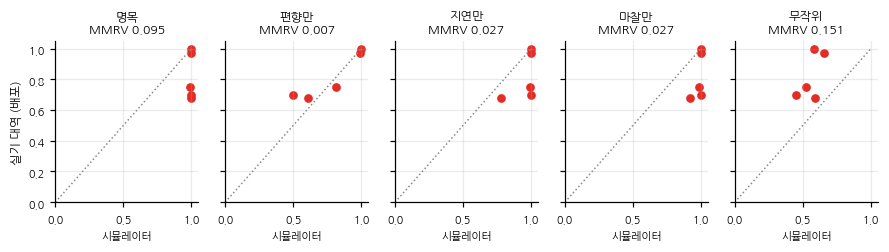

In [12]:
fig, axs = plt.subplots(1, 5, figsize=(8.2, 2.4), sharey=True)
for a, d in zip(axs, DESIGNS):
    S = [SC[(k, d)] for k in CANDS]
    a.scatter(S, REAL, color=RED, s=22)
    a.plot([0, 1], [0, 1], ":", color=GREY, lw=1)
    a.set_title(f"{d}\nMMRV {GAP[d][1]:.3f}", fontsize=8)
    a.set_xlim(0, 1.05)
    a.set_ylim(0, 1.05)
    a.set_xlabel("시뮬레이터", fontsize=7)
    a.tick_params(labelsize=7)
axs[0].set_ylabel("실기 대역 (배포)", fontsize=8)
plt.tight_layout()
plt.show()

## 평가 설계를 남긴다

규칙을 코드로 적는다. **MMRV 가 가장 작은 설계**를 4~6부의 시뮬레이터 평가 설계로 쓴다. 동률이면 피어슨 r 이 큰 쪽이다.

In [13]:
pick = min(DESIGNS,
           key=lambda d: (GAP[d][1], -np.nan_to_num(GAP[d][0])))
os.makedirs("gap", exist_ok=True)
OUT = {"real_proxy": "배포", "pick": pick,
       "designs": {d: {"pearson": round(float(GAP[d][0]), 3),
                       "mmrv": round(GAP[d][1], 3),
                       "mean_gap": round(float(GAP[d][2]), 3)}
                   for d in DESIGNS},
       "scores": {k: {d: round(SC[(k, d)], 3)
                      for d in DESIGNS + ["배포"]}
                  for k in CANDS}}
with open("gap/eval_design.json", "w") as f:
    json.dump(OUT, f, ensure_ascii=False, indent=1)
save_log("report/ch10_log.csv", LOG)
print(f"고른 평가 설계: {pick}")
print()
print("남긴 산출물")
print("  gap/eval_design.json  설계별 r·MMRV·갭, 후보별 성적")
print(f"  report/ch10_log.csv   판별 로그 {len(LOG):,}줄")

고른 평가 설계: 편향만

남긴 산출물
  gap/eval_design.json  설계별 r·MMRV·갭, 후보별 성적
  report/ch10_log.csv   판별 로그 24,066줄


## 정리

**명목 시뮬레이터는 후보를 가르지 못한다.** 다섯 후보가 모두 0.99 이상이고, MMRV 가 0.095다.

**교란 하나를 정확히 넣은 설계가 순위를 가장 잘 예고했다.** 편향만 넣은 설계가 MMRV 0.007, 피어슨 r 0.923이다. 이 과제의 실기 대역에서 후보를 가른 것은 관측 편향이었다.

**넓게 흔든다고 현장에 가까워지지 않는다.** 넓은 무작위 설계가 MMRV 0.151로 가장 나빴다.

**평가 설계는 `gap/eval_design.json` 에 남겼다.** 이 결론은 실기 대역 하나에 묶여 있다. 대역이 달라지면 어떻게 되는지는 12장이 잰다.